In [1]:
import pandas as pd

import os
import s3fs


fs = s3fs.S3FileSystem(
    client_kwargs={'endpoint_url': 'https://'+'minio.lab.sspcloud.fr'},
    key = os.environ["AWS_ACCESS_KEY_ID"], 
    secret = os.environ["AWS_SECRET_ACCESS_KEY"], 
    token = os.environ["AWS_SESSION_TOKEN"])

"""
with fs.open("s3://lab/art_net_dec.parquet") as f : 
    dfa = pd.read_parquet(f)



with fs.open("s3://lab/conf_net_dec.parquet") as f : 
    dfc = pd.read_parquet(f)"""

#with fs.open("s3://lab/mem/full_name_list.csv") as f : 
   # nl = pd.read_csv(f, index_col=[0])
"""
with fs.open("s3://lab/mem/n_to_g.csv") as f : 
    ntg = pd.read_csv(f, index_col=[0])"""
"""
with fs.open("s3://lab/kgnd.csv") as f:
    kgnd = pd.read_csv(f)
with fs.open("s3://lab/ignd.csv") as f:
    ignd = pd.read_csv(f)
with fs.open("s3://lab/wgnd.csv") as f:
    wgnd = pd.read_csv(f)
with fs.open("s3://lab/jgnd.csv") as f:
    jgnd = pd.read_csv(f)
with fs.open("s3://lab/cgnd.csv") as f:
    cgnd = pd.read_csv(f)
with fs.open("s3://lab/usgnd.csv") as f: 
    usgnd = pd.read_csv(f)"""

'\nwith fs.open("s3://lab/kgnd.csv") as f:\n    kgnd = pd.read_csv(f)\nwith fs.open("s3://lab/ignd.csv") as f:\n    ignd = pd.read_csv(f)\nwith fs.open("s3://lab/wgnd.csv") as f:\n    wgnd = pd.read_csv(f)\nwith fs.open("s3://lab/jgnd.csv") as f:\n    jgnd = pd.read_csv(f)\nwith fs.open("s3://lab/cgnd.csv") as f:\n    cgnd = pd.read_csv(f)\nwith fs.open("s3://lab/usgnd.csv") as f: \n    usgnd = pd.read_csv(f)'

ATTR df

In [13]:
import pandas as pd
with fs.open("s3://lab/wgnd.csv") as f:
    wgnd = pd.read_csv(f)

wgnd = wgnd.rename(columns={"Name":"name", "Gender" : "gender"})
wgnd = wgnd.drop_duplicates()
wgnd

,name,gender
0,baby,F
1,aisyah,F
2,anela,F
4,fiyinfoluwa,F
6,olioni,M
...,...,...
21831032,hyihwa,F
21831033,hyihwan,M
21831034,hyihun,M
21831037,hiyori,F


In [3]:
with fs.open("s3://lab/art_net_dec.parquet") as f : 
    dfa = pd.read_parquet(f)
dfa

,title,journal,year,authors,dblp_uri,doi
0,Auswirkung der Digitalisierung auf die Systeml...,Elektrotech. Informationstechnik,2019,"[{'name': 'Kai Schlabitz', 'orcid': None}]",journals/ei/Schlabitz19,https://doi.org/10.1007/s00502-019-0687-y
1,EMF-Personenschutz: Neue Aspekte in der numeri...,Elektrotech. Informationstechnik,2020,"[{'name': 'Richard Überbacher', 'orcid': None}...",journals/ei/UberbacherC20,https://doi.org/10.1007/s00502-020-00791-z
2,Zur Genesis der Forschungsstelle für Integrier...,Elektrotech. Informationstechnik,2022,"[{'name': 'Herbert Mang', 'orcid': None}]",journals/ei/Mang22,https://doi.org/10.1007/s00502-022-01049-6
3,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,"[{'name': 'Sophie Knöttner', 'orcid': None}, {...",journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7
4,Application of multilateration for microphone ...,Elektrotech. Informationstechnik,2021,[],journals/ei/WimbergerR21,https://doi.org/10.1007/s00502-021-00885-2
...,...,...,...,...,...,...
3992218,"Derivability, Redundancy and Consistency of Re...","Research Report / RJ / IBM / San Jose, California",1969,"[{'name': 'E. F. Codd', 'orcid': None}]",persons/Codd69,None
3992219,Normalized Data Base Structure: A Brief Tutorial.,"Research Report / RJ / IBM / San Jose, California",1971,"[{'name': 'E. F. Codd', 'orcid': None}]",persons/Codd71b,None
3992220,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,"[{'name': 'Gayane Grigoryan', 'orcid': None}, ...",persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217
3992221,Common Subexpression Identification in General...,"Technical Rep. UKSC 0060, IBM United Kingdom S...",1974,"[{'name': 'Patrick A. V. Hall', 'orcid': None}]",persons/Hall74,None


In [4]:
#to etract citations

dfa["citations"] = pd.NA

for i in range(1,407):
    with fs.open(f"s3://lab/cite/dblp_{i}.csv") as f:
        temp = pd.read_csv(f)
    temp["dblp_uri"] = temp["dblp_uri"].str.replace(
        "https://dblp.org/rec/", "", regex=False
    )
    temp_map = (
        temp.drop_duplicates("dblp_uri")
          .set_index("dblp_uri")["citations"]
    )
    
    dfa["citations"] = (
        dfa["citations"]
        .combine_first(dfa["dblp_uri"].map(temp_map))
    )

/tmp/ipykernel_7130/4097367981.py:18: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  .combine_first(dfa["dblp_uri"].map(temp_map))


In [5]:
dfa["authors"] = dfa["authors"].apply(lambda lst: [d["name"] for d in lst])
attr = dfa.explode("authors")
attr = attr.groupby("authors", as_index=False).agg({col: list for col in attr.columns if col != "authors"})

In [6]:
import re, string

attr["name"] = attr["authors"].str.split(" ").str[0].str.lower()
punct = re.escape(string.punctuation)
attr["name"] = attr["name"].str.replace(f'[{punct}]', '', regex=True)

In [17]:
attr = attr.merge(wgnd,how="left",on="name")
attr

,authors,title,journal,year,dblp_uri,doi,citations,name,gender
0,'Damola Adediji,"[Undermining competition, undermining markets?...",[Big Data Soc.],[2025],[journals/bigdatasociety/BirchA25],[None],[nan],damola,M
1,'Maseka Lesaoana,[A transportation branch and bound algorithm f...,"[Int. J. Syst. Assur. Eng. Manag., Oper. Res.]","[2015, 2001]","[journals/saem/MunapoLNK15, journals/ior/HallL...","[https://doi.org/10.1007/s13198-015-0343-9, ht...","[8.0, 70.0]",maseka,NaN
2,'Osaiasi Lolohea,[Visual literacy shown through a magnifying le...,[Interact. Technol. Smart Educ.],[2023],[journals/itse/ReddySCLT23],[https://doi.org/10.1108/ITSE-01-2022-0007],[2.0],osaiasi,NaN
3,(David) Jing Dai,[AutonomousGIS 2017 workshop report: the First...,[ACM SIGSPATIAL Special],[2017],[journals/sigspatial/GaoDHXC17],[https://doi.org/10.1145/3178392.3178407],[nan],david,M
4,(Max) Zong-Ming Cheng,[MicroSyn: A user friendly tool for detection ...,"[BMC Bioinform., BMC Bioinform.]","[2011, 2009]","[journals/bmcbi/CaiYTC11, journals/bmcbi/XuZHZ...","[https://www.wikidata.org/entity/Q28741346, ht...","[35.0, 186.0]",max,M
...,...,...,...,...,...,...,...,...,...
2700980,Þorsteinn Sæmundsson,[Inferring 2D Local Surface-Deformation Veloci...,[Remote. Sens.],[2022],[journals/remotesensing/DittrichHTS22],[None],[4.0],þorsteinn,NaN
2700981,Þröstur Pétursson,[Bone Mineral Density and Fracture Risk Assess...,[Comput. Math. Methods Medicine],[2015],[journals/cmmm/PeturssonEGMMHJ15],[https://www.wikidata.org/entity/Q36055821],[21.0],þröstur,NaN
2700982,Þórhildur Þorleiksdóttir,[Exquisitor: Interactive Learning at Large.],[CoRR],[2019],[journals/corr/abs-1904-08689],[None],[nan],þórhildur,NaN
2700983,Þórir Hrafn Harðarson,[Aligning Language Models for Icelandic Legal ...,[CoRR],[2025],[journals/corr/abs-2504-18180],[None],[nan],þórir,NaN


In [18]:
import numpy as np

attr["max_cite"] = attr["citations"].apply(np.max)

attr["mean_cite"] = attr["citations"].apply(np.mean)

In [22]:
attr.to_parquet("s3://lab/mem/art_attr.parquet")

EDGES df

In [28]:
from itertools import combinations

rows = []
for _, row in dfa.iterrows():
    for sender, receiver in combinations(row["authors"], 2):
        new_row = row.to_dict()
        new_row["sender"] = sender
        new_row["receiver"] = receiver
        rows.append(new_row)

edges_df = pd.DataFrame(rows).drop(columns=["authors"])

In [ ]:
with fs.open("s3://lab/CORE_journals_corr.csv") as f : 
    rank = pd.read_csv(f)

edges_df = edges_df.merge(rank[["abrv","rank"]], left_on="journal",right_on="abrv",how="left")

In [21]:
edges_df.to_parquet("s3://lab/mem/art_edges.parquet")

In [ ]:
# NA
len(attr[attr["gender"].isna()])/len(attr)

0.09237476842307255

Network modelisation

In [22]:
import pandas as pd
with fs.open("s3://lab/mem/art_edges.parquet") as f : 
    edges = pd.read_parquet(f)

edges

,title,journal,year,dblp_uri,doi,citations,sender,receiver,abrv,rank
0,EMF-Personenschutz: Neue Aspekte in der numeri...,Elektrotech. Informationstechnik,2020,journals/ei/UberbacherC20,https://doi.org/10.1007/s00502-020-00791-z,NaN,Richard Überbacher,Stefan Cecil,None,None
1,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Sophie Knöttner,Roman Geyer,None,None
2,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Sophie Knöttner,Christian Diendorfer,None,None
3,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Sophie Knöttner,Gerwin H. S. Drexler-Schmid,None,None
4,100 % erneuerbare Energie für Österreichs Indu...,Elektrotech. Informationstechnik,2021,journals/ei/KnottnerGDD21,https://doi.org/10.1007/s00502-021-00953-7,NaN,Roman Geyer,Christian Diendorfer,None,None
...,...,...,...,...,...,...,...,...,...,...
17676648,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gronz,Rita Ley,None,None
17676649,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gronz,Andreas Rock,None,None
17676650,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gutjahr,Rita Ley,None,None
17676651,Analysis of projected hydrological behavior of...,Hydrology and Earth System Sciences,2012,persons/CasperGGGHLR12,https://www.wikidata.org/entity/Q114958217,25.0,Oliver Gutjahr,Andreas Rock,None,None


In [13]:
with fs.open("s3://lab/mem/art_attr.parquet") as f : 
    attr = pd.read_parquet(f)

attr

,authors,title,journal,year,dblp_uri,doi,citations,name,gender,max_cite,mean_cite
0,'Damola Adediji,"[Undermining competition, undermining markets?...",[Big Data Soc.],[2025],[journals/bigdatasociety/BirchA25],[None],[nan],damola,M,NaN,NaN
1,'Maseka Lesaoana,[A transportation branch and bound algorithm f...,"[Int. J. Syst. Assur. Eng. Manag., Oper. Res.]","[2015, 2001]","[journals/saem/MunapoLNK15, journals/ior/HallL...","[https://doi.org/10.1007/s13198-015-0343-9, ht...","[8.0, 70.0]",maseka,None,70.0,39.0
2,'Osaiasi Lolohea,[Visual literacy shown through a magnifying le...,[Interact. Technol. Smart Educ.],[2023],[journals/itse/ReddySCLT23],[https://doi.org/10.1108/ITSE-01-2022-0007],[2.0],osaiasi,None,2.0,2.0
3,(David) Jing Dai,[AutonomousGIS 2017 workshop report: the First...,[ACM SIGSPATIAL Special],[2017],[journals/sigspatial/GaoDHXC17],[https://doi.org/10.1145/3178392.3178407],[nan],david,M,NaN,NaN
4,(Max) Zong-Ming Cheng,[MicroSyn: A user friendly tool for detection ...,"[BMC Bioinform., BMC Bioinform.]","[2011, 2009]","[journals/bmcbi/CaiYTC11, journals/bmcbi/XuZHZ...","[https://www.wikidata.org/entity/Q28741346, ht...","[35.0, 186.0]",max,M,186.0,110.5
...,...,...,...,...,...,...,...,...,...,...,...
2700980,Þorsteinn Sæmundsson,[Inferring 2D Local Surface-Deformation Veloci...,[Remote. Sens.],[2022],[journals/remotesensing/DittrichHTS22],[None],[4.0],þorsteinn,None,4.0,4.0
2700981,Þröstur Pétursson,[Bone Mineral Density and Fracture Risk Assess...,[Comput. Math. Methods Medicine],[2015],[journals/cmmm/PeturssonEGMMHJ15],[https://www.wikidata.org/entity/Q36055821],[21.0],þröstur,None,21.0,21.0
2700982,Þórhildur Þorleiksdóttir,[Exquisitor: Interactive Learning at Large.],[CoRR],[2019],[journals/corr/abs-1904-08689],[None],[nan],þórhildur,None,NaN,NaN
2700983,Þórir Hrafn Harðarson,[Aligning Language Models for Icelandic Legal ...,[CoRR],[2025],[journals/corr/abs-2504-18180],[None],[nan],þórir,None,NaN,NaN


In [31]:
%pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 84.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [23]:
edges = edges[edges["year"].astype(int)>1980]

In [ ]:
for _, row in edges_df.iterrows():
    G.add_edge(
        row["sender"], row["receiver"],
        year=row["year"],
        rank=row["rank"],
        citations=row["citations"]
    )

In [ ]:
import networkx as nx

G = nx.Graph()

for _, row in edges.iterrows():
    G.add_edge(
        row["sender"], row["receiver"],
        year=row["year"],
        rank=row["rank"],
        citations=row["citations"]
    )

for _, row in attr[["authors","gender","mean_cite"]].iterrows():
    if row["authors"] in G.nodes:
        G.nodes[row["authors"]].update(row.to_dict())

KeyError: 'authors'

In [26]:
G.remove_edges_from(nx.selfloop_edges(G))

In [27]:
graphs = list(nx.connected_components(G))

3 graphs à plus de 50 membres → on retient que le premier graph et les autres sont considérés comme des teams ? nn on garde que le gros

In [28]:
big_graphs = []

for i in graphs : 
    if len(i)>50 : 
        big_graphs.append(i)
len(big_graphs)

3

In [29]:
core = G.subgraph(graphs[0]).copy()

In [39]:
import pickle

# Save
with fs.open("s3://lab/mem/core_graph.pkl", "wb") as f:
    pickle.dump(core, f)

In [38]:
u, v, d = list(core.edges(data=True))[0]
print(u, v, d)

Richard Überbacher Stefan Cecil {'year': '2020', 'rank': None, 'citations': nan}


identifier les commu

In [3]:
import pickle
with fs.open("s3://lab/mem/core_graph.pkl", "rb") as f:
    core = pickle.load(f)

In [20]:
import networkx as nx

degree_dict = dict(core.degree())

rc = nx.rich_club_coefficient(core, normalized=False)

In [5]:
import pandas as pd

df_nodes = pd.DataFrame([
    {"name": node, "degree": degree_dict[node], **data}
    for node, data in core.nodes(data=True)
])

df_nodes["rc_coefficient"] = df_nodes["degree"].map(rc)

df_nodes

,name,degree,authors,gender,mean_cite,rc_coefficient
0,Richard Überbacher,1,Richard Überbacher,M,NaN,0.000008
1,Stefan Cecil,5,Stefan Cecil,M,NaN,0.000026
2,Sophie Knöttner,3,Sophie Knöttner,F,NaN,0.000015
3,Roman Geyer,3,Roman Geyer,M,NaN,0.000015
4,Christian Diendorfer,3,Christian Diendorfer,M,NaN,0.000015
...,...,...,...,...,...,...
1863120,Sebastian Mossburger,3,Sebastian Mossburger,M,NaN,0.000015
1863121,Hugo Hellebrand,2,Hugo Hellebrand,M,105.0,0.000011
1863122,Oliver Gronz,4,Oliver Gronz,M,25.0,0.000020
1863123,Oliver Gutjahr,4,Oliver Gutjahr,M,21.0,0.000020


In [12]:
from sklearn.linear_model import LogisticRegression
import statsmodels.formula.api as smf

model = smf.ols("rc_coefficient ~ C(gender, Treatment('M')) + mean_cite + mean_cite:C(gender, Treatment('M'))", data=df_nodes).fit() #F ref bc alphabetic order
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         rc_coefficient   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1180.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:10:10   Log-Likelihood:             2.9852e+06
No. Observations:              628933   AIC:                        -5.970e+06
Df Residuals:                  628929   BIC:                        -5.970e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

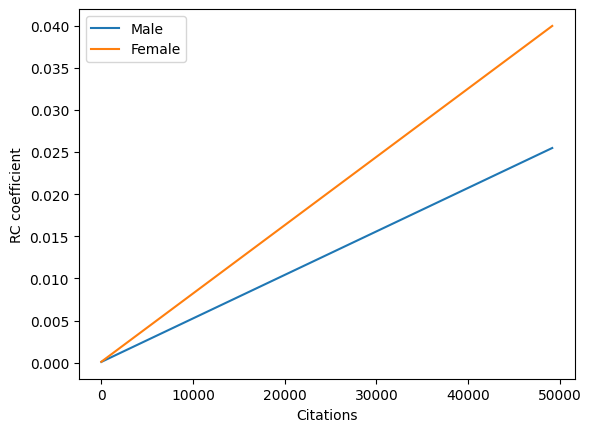

In [14]:
import numpy as np
import matplotlib.pyplot as plt

citations = np.linspace(0, df_nodes["mean_cite"].max(), 100)

rc_male = 0.0001 + 5.161e-07 * citations
rc_female = (0.0001 + 1.977e-05) + (5.161e-07 + 2.941e-07) * citations

plt.plot(citations, rc_male, label="Male")
plt.plot(citations, rc_female, label="Female")
plt.xlabel("Citations")
plt.ylabel("RC coefficient")
plt.legend()

In [15]:
%pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 22.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 93.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [leidenalg]/3 [leidenalg]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import igraph as ig
import leidenalg
import pandas as pd
import numpy as np

# 1. Convert to igraph
node_list = list(core.nodes())
node_idx = {n: i for i, n in enumerate(node_list)}

edges = [(node_idx[u], node_idx[v]) for u, v in core.edges()]

g_ig = ig.Graph(n=len(node_list), edges=edges, directed=False)
g_ig.vs["name"] = node_list
g_ig.vs["id"] = list(range(len(node_list)))

# add node attributes
for attr in ["gender", "mean_cite"]:
    g_ig.vs[attr] = [core.nodes[n].get(attr, None) for n in node_list]

# 2. Run Leiden
partition = leidenalg.find_partition(
    g_ig,
    leidenalg.RBConfigurationVertexPartition,
    resolution_parameter=2.0
)

# 3. Build results dataframe
df_nodes = pd.DataFrame({
    "name":      g_ig.vs["name"],
    "community": partition.membership,
    "gender":    g_ig.vs["gender"],
    "mean_cite": g_ig.vs["mean_cite"],
    "degree":    g_ig.degree()
})

# 4. Community stats
comm_stats = df_nodes.groupby("community").agg(
    size       = ("name", "count"),
    pct_female = ("gender", lambda x: (x == "F").mean()),
    mean_cite  = ("mean_cite", "mean"),
    mean_degree= ("degree", "mean")
).reset_index()

# 5. Flag elite
threshold = comm_stats["mean_cite"].quantile(0.95)
comm_stats["is_elite"] = comm_stats["mean_cite"] >= threshold

print(comm_stats[comm_stats["is_elite"]])

     community   size  pct_female   mean_cite  mean_degree  is_elite
0            0  66530    0.261566   15.094365    27.746460      True
15          15  27497    0.325454   34.565956    22.953268      True
18          18  24819    0.347597   42.338243    36.415126      True
20          20  20235    0.298641   55.804675    30.176921      True
27          27  16797    0.264750   20.858680    33.764125      True
50          50   9841    0.261660   16.341012    21.884971      True
58          58   8677    0.286044   19.635771    20.900772      True
60          60   8202    0.268349   16.600957    19.997074      True
61          61   8105    0.326465   37.173056    23.001110      True
63          63   7861    0.346648  199.377123    21.790357      True
73          73   6280    0.285191   25.218463    20.791561      True
80          80   5606    0.282554   23.721819    28.906885      True
81          81   5489    0.280561   33.264260    25.296411      True
128        128   3493    0.278843 

In [22]:
df_nodes["rc_coefficient"] = df_nodes["degree"].map(rc)
df_nodes

,name,community,gender,mean_cite,degree,rc_coefficient
0,Richard Überbacher,146,M,NaN,1,0.000008
1,Stefan Cecil,146,M,NaN,5,0.000026
2,Sophie Knöttner,194,F,NaN,3,0.000015
3,Roman Geyer,194,M,NaN,3,0.000015
4,Christian Diendorfer,194,M,NaN,3,0.000015
...,...,...,...,...,...,...
1863120,Sebastian Mossburger,13,M,NaN,3,0.000015
1863121,Hugo Hellebrand,95,M,105.0,2,0.000011
1863122,Oliver Gronz,95,M,25.0,4,0.000020
1863123,Oliver Gutjahr,95,M,21.0,4,0.000020


In [23]:
comm_stats = df_nodes.groupby("community").agg(
    size       = ("name", "count"),
    pct_female = ("gender", lambda x: (x == "F").mean()),
    mean_cite  = ("mean_cite", "mean"),
    mean_degree= ("degree", "mean"),
    mean_rc= ("rc_coefficient", "mean")
).reset_index()

In [25]:
threshold = comm_stats["mean_rc"].quantile(0.95)
comm_stats["is_elite"] = comm_stats["mean_rc"] >= threshold

print(comm_stats[comm_stats["is_elite"]])

     community   size  pct_female   mean_cite  mean_degree   mean_rc  is_elite
0            0  66530    0.261566   15.094365    27.746460  0.001671      True
15          15  27497    0.325454   34.565956    22.953268  0.001099      True
18          18  24819    0.347597   42.338243    36.415126  0.002860      True
20          20  20235    0.298641   55.804675    30.176921  0.001623      True
27          27  16797    0.264750   20.858680    33.764125  0.003139      True
50          50   9841    0.261660   16.341012    21.884971  0.001128      True
57          57   8751    0.279625   16.849719    19.690207  0.001484      True
58          58   8677    0.286044   19.635771    20.900772  0.001148      True
59          59   8570    0.267211   18.710319    19.480630  0.001314      True
60          60   8202    0.268349   16.600957    19.997074  0.001855      True
61          61   8105    0.326465   37.173056    23.001110  0.000847      True
63          63   7861    0.346648  199.377123    21.

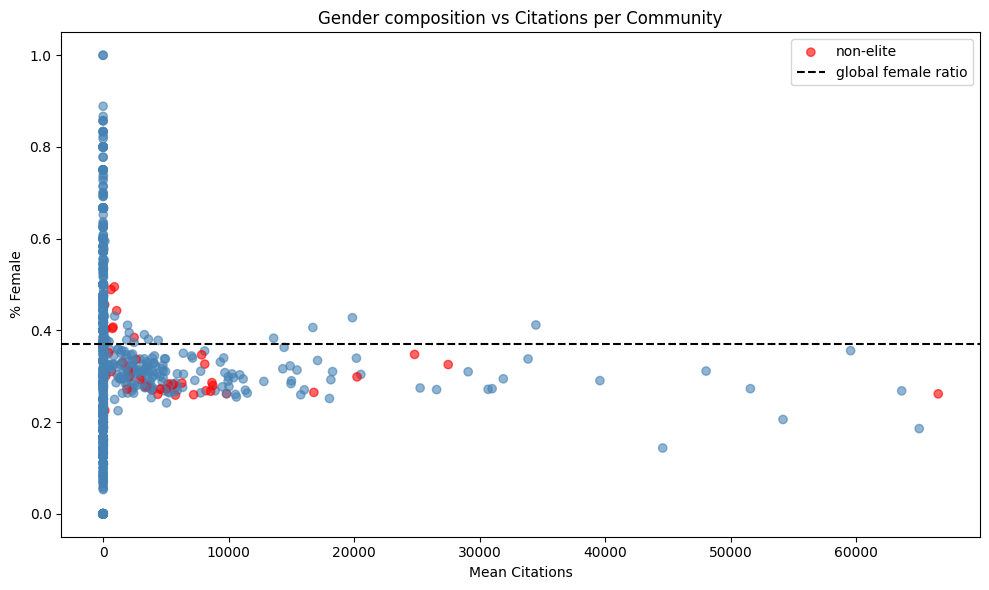

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    comm_stats["size"],
    comm_stats["pct_female"],
    c=comm_stats["is_elite"].map({True: "red", False: "steelblue"}),
    alpha=0.6
)

# 37.1% reference line
ax.axhline(y=0.371, color="black", linestyle="--", label="37.1% baseline")

ax.set_xlabel("Mean Citations")
ax.set_ylabel("% Female")
ax.set_title("Gender composition vs Citations per Community")
ax.legend(["non-elite", "global female ratio", "Elite"])

plt.tight_layout()
plt.show()

In [37]:
import statsmodels.formula.api as smf

quantiles = [0.25, 0.50, 0.75, 0.90, 0.93, 0.95, 0.97, 0.99]

for q in quantiles:
    model = smf.quantreg(
        "rc_coefficient ~ C(gender, Treatment('M')) + mean_cite + mean_cite:C(gender, Treatment('M'))",
        data=df_nodes
    ).fit(q=q)
    print(f"\nQuantile {q}")
    print(model.summary())


Quantile 0.25
                         QuantReg Regression Results                          
Dep. Variable:         rc_coefficient   Pseudo R-squared:            -0.007572
Model:                       QuantReg   Bandwidth:                   8.414e-07
Method:                 Least Squares   Sparsity:                    0.0001120
Date:                Sun, 26 Apr 2026   No. Observations:               628933
Time:                        14:57:32   Df Residuals:                   628929
                                        Df Model:                            3
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
Intercept                                 1.367e-05   8.83e-08    154.772      0.000    1.35e-05    1.38e-05
C(gender, Treatment('M'))[T.F]           -6.792e-07   1.42e-07     -4.777      0.000   -9.58e-07   -4.01e

In [ ]:
gender_coefs = []
gender_ci_low = []
gender_ci_high = []
for q in quantiles:
    model = smf.quantreg(
        "rc_coefficient ~ C(gender, Treatment('M')) + mean_cite + mean_cite:C(gender, Treatment('M'))",
        data=df_nodes
    ).fit(q=q)
    
    coef = model.params["C(gender, Treatment('M'))[T.F]"]
    ci = model.conf_int().loc["C(gender, Treatment('M'))[T.F]"]
    gender_coefs.append(coef)
    gender_ci_low.append(ci[0])
    gender_ci_high.append(ci[1])

ols = smf.ols(
    "rc_coefficient ~ C(gender, Treatment('M')) + mean_cite + mean_cite:C(gender, Treatment('M'))",
    data=df_nodes
).fit()

ols_coef = ols.params["C(gender, Treatment('M'))[T.F]"]

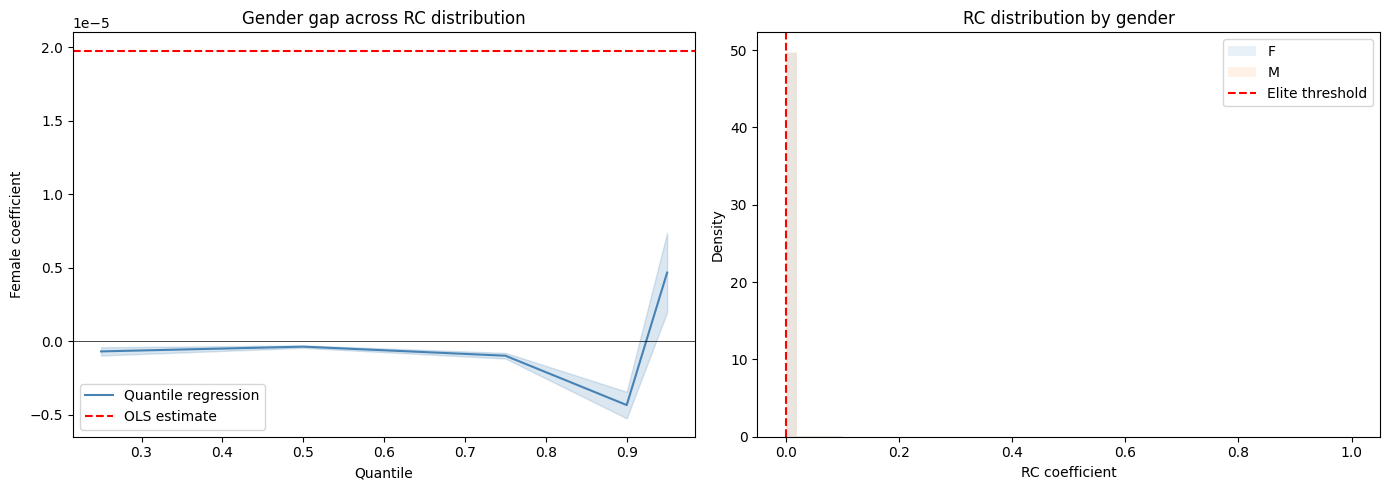

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: quantile coefficients ───────────────────────────────────────────────
axes[0].plot(quantiles, gender_coefs, color="steelblue", label="Quantile regression")
axes[0].fill_between(quantiles, gender_ci_low, gender_ci_high, alpha=0.2, color="steelblue")
axes[0].axhline(ols_coef, color="red", linestyle="--", label="OLS estimate")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("Quantile")
axes[0].set_ylabel("Female coefficient")
axes[0].set_title("Gender gap across RC distribution")
axes[0].legend()

# ── Right: rc distribution by gender ─────────────────────────────────────────
for gender, group in df_nodes.groupby("gender"):
    axes[1].hist(group["rc_coefficient"], bins=50, alpha=0.5, label=gender, density=True)
axes[1].axvline(df_nodes["rc_coefficient"].quantile(0.95), 
                color="red", linestyle="--", label="Elite threshold")
axes[1].set_xlabel("RC coefficient")
axes[1].set_ylabel("Density")
axes[1].set_title("RC distribution by gender")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
len(df_nodes[df_nodes["gender"]=="M"])/len(df_nodes[~df_nodes["gender"].isna()])

0.6291764986763667

In [ ]:
for g_year in graphs:
    g_year.vs["id"] = list(range(g_year.vcount()))
partitions, interslice = leidenalg.find_partition_temporal(
    graphs,
    leidenalg.RBConfigurationVertexPartition,
    interslice_weight=0.1,   # increase for more stable communities over time
    resolution_parameter=5.0
)

In [ ]:
results = []

for year, g_year, partition in zip(valid_years, graphs, partitions):
    
    # add community membership to graph
    g_year.vs["community"] = partition.membership
    
    # build a dataframe of nodes for this year
    df_year = pd.DataFrame({
        "name":      g_year.vs["name"],
        "community": g_year.vs["community"],
        "gender":    g_year.vs["gender"],
        "mean_cite": g_year.vs["mean_cite"],
        "degree":    [g_year.degree(i) for i in range(n_nodes)],
        "year":      year
    })
    
    # community-level stats
    comm_stats = df_year.groupby("community").agg(
        size        = ("name", "count"),
        pct_female  = ("gender", lambda x: (x == "F").mean()),
        mean_cite   = ("mean_cite", "mean"),
        mean_degree = ("degree", "mean")
    ).reset_index()
    
    comm_stats["year"] = year
    
    # flag elite communities (top 5% by mean degree)
    threshold = comm_stats["mean_degree"].quantile(0.95)
    comm_stats["is_elite"] = comm_stats["mean_degree"] >= threshold
    
    results.append(comm_stats)

df_results = pd.concat(results, ignore_index=True)


elite_gender = (
    df_results[df_results["is_elite"]]
    .groupby("year")["pct_female"]
    .mean()
    .reset_index()
)

print(elite_gender)


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# % female in elite communities over time
axes[0].plot(elite_gender["year"], elite_gender["pct_female"])
axes[0].set_title("% Female in Elite Communities over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("% Female")

# overall % female vs elite % female
overall_gender = (
    df_results.groupby("year")["pct_female"].mean().reset_index()
)
axes[1].plot(overall_gender["year"], overall_gender["pct_female"], label="Overall")
axes[1].plot(elite_gender["year"], elite_gender["pct_female"], label="Elite")
axes[1].set_title("Overall vs Elite % Female")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    "pct_female ~ is_elite + mean_cite + year", 
    data=df_results
).fit()
print(model.summary())

In [ ]:
graphs = []
for year in range(2000, 2024):
    edges = df[df["year"] == year][["source", "target"]].values.tolist()
    g_year = ig.Graph(n=n_nodes, edges=edges)
    graphs.append(g_year)

partition, interslice = leidenalg.find_partition_temporal(
    graphs,
    leidenalg.RBConfigurationVertexPartition,
    interslice_weight=0.1,
    resolution_parameter=2.0
)

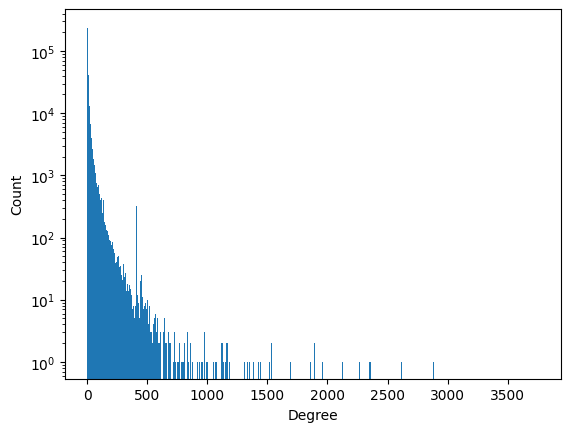

In [48]:
import matplotlib.pyplot as plt
import numpy as np
degree_sequence = sorted((d for n, d in core.degree()), reverse=True)
plt.hist(degree_sequence, bins=range(min(degree_sequence), max(degree_sequence) + 2))
plt.yscale("log")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

In [43]:
nx.average_node_connectivity(core)

KeyboardInterrupt: 

In [ ]:
nx.flow_hierarchy(core)